# NumPyro implementation of the 2 moons distribution

In [ ]:
!pip install numpyro
!pip install diffrax

In [ ]:
%pylab inline
import jax
import jax.numpy as np
import numpyro.distributions as dist

In [17]:
@jax.jit
def make_two_mooons(sigma):
  """
  Function that gives you the log probability of the two moons distribution.
  """
  resolution = 1024
  outer_circ_x = np.cos(np.linspace(0, np.pi, resolution))
  outer_circ_y = np.sin(np.linspace(0, np.pi, resolution))
  inner_circ_x = 1 - np.cos(np.linspace(0, np.pi, resolution))
  inner_circ_y = 1 - np.sin(np.linspace(0, np.pi, resolution)) - .5

  X = np.append(outer_circ_x, inner_circ_x)
  Y = np.append(outer_circ_y, inner_circ_y)
  coords = np.vstack([X,Y])

  base_sigma=0.05
  s = np.sqrt(sigma**2 + base_sigma**2)
  # We approximate the 2 moons with a large mixture
  distribution = dist.MixtureSameFamily(
      dist.Categorical(probs=np.ones(2*resolution)/resolution/2),
      dist.MultivariateNormal(loc=coords.T, scale_tril=s*np.eye(2)[None].repeat(2*resolution, axis=0))
  )
  return distribution

(-1.0, 2.0)

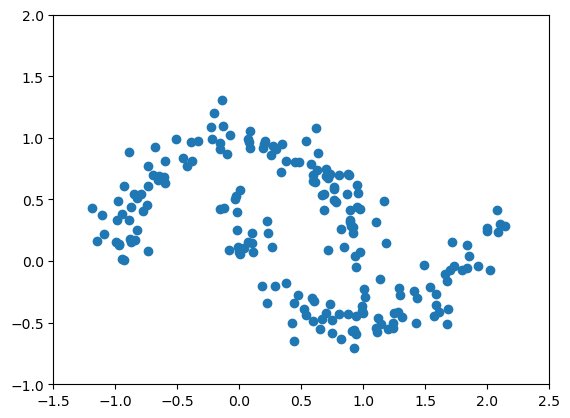

In [18]:
# Sample from the distribution and plot it
rng_key = jax.random.PRNGKey(seed=0)
distribution = make_two_mooons(0.1)
samps = distribution.sample(rng_key, sample_shape=(200,))

scatter(samps[:,0], samps[:,1])
xlim(-1.5,-1.5+4)
ylim(-1.,-1.+3)

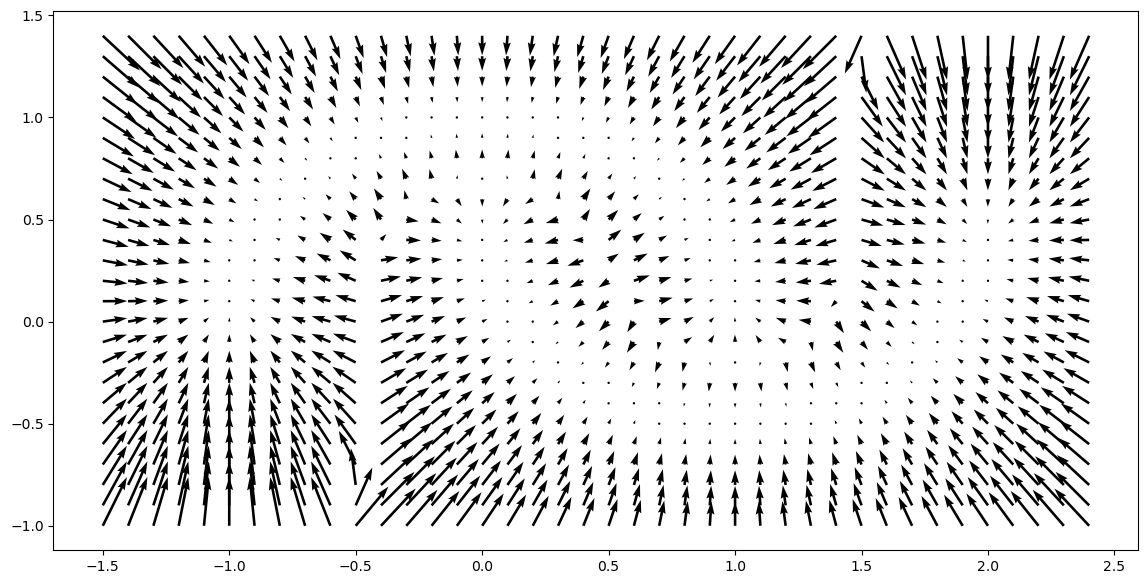

In [20]:
# But now we can also compute the gradients of log p :-)
grads = jax.vmap(jax.grad(distribution.log_prob))

X = np.arange(-1.5, 2.5, 0.1)
Y = np.arange(-1, 1.5, 0.1)
points = stack(meshgrid(X, Y), axis=-1).reshape((-1, 2))
g = grads(points).reshape([len(Y), len(X),2])

figure(figsize=(14,7))
quiver(X, Y, g[:,:,0], g[:,:,1]);

## Implementation of a diffusion model

In [24]:
import jax
import jax.numpy as jnp
import diffrax
import lineax as lx

def log_p(x, sigma=0.):
  return make_two_mooons(sigma).log_prob(x).squeeze()

score_fn = jax.vmap(jax.grad(log_p), in_axes=(0,None))

def ve_sde_sample(score_fn, x_init, key, sigma_min=0.01, sigma_max=10.0, N=128):
    """Sample from a VE-SDE diffusion model via reverse-time SDE.

    Forward VE-SDE:  dx = sqrt(d[sigma^2(t)]/dt) dw
    Reverse VE-SDE:  dx = -sigma(t)^2 * score(x, t) dt + sigma(t) dw_bar

    with sigma(t) = sigma_min * (sigma_max/sigma_min)^t
    """

    def sigma(t):
        return sigma_min * (sigma_max / sigma_min) ** t

    def drift(t, y, args):
        s = sigma(t)
        # d[sigma^2]/dt = sigma^2 * 2*log(sigma_max/sigma_min)
        score = score_fn(y, s)
        return -s**2 * 2 * jnp.log(sigma_max / sigma_min) * score

    def diffusion(t, y, args):
        s = sigma(t)
        diffusion_coeff_scalar = s * jnp.sqrt(2 * jnp.log(sigma_max / sigma_min))
        # Return a Lineax DiagonalLinearOperator as recommended by Diffrax 0.7.0+
        diagonal = jnp.full(y.shape[-1], diffusion_coeff_scalar) # Create a diagonal vector of size num_dims
        return lx.DiagonalLinearOperator(diagonal)

    # Reverse time: integrate from t=1 to t=0
    brownian_motion = diffrax.VirtualBrownianTree(
        t0=0.0, t1=1.0, tol=1e-3, shape=x_init.shape, key=key
    )

    terms = diffrax.MultiTerm(
        diffrax.ODETerm(drift),
        diffrax.ControlTerm(diffusion, brownian_motion),
    )

    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        terms,
        solver,
        t0=1.0,
        t1=0.0,
        dt0=-1.0 / N,
        y0=x_init,
        args=None,
        saveat=diffrax.SaveAt(ts=jnp.linspace(1.0, 0.0, N))
    )

    return sol.ys


key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
x_init = jax.random.normal(k1, (128,2))  # start from noise

sample_score_fn = jax.vmap(jax.grad(log_p), in_axes=(0,None))

samples = ve_sde_sample(sample_score_fn, x_init, k2)

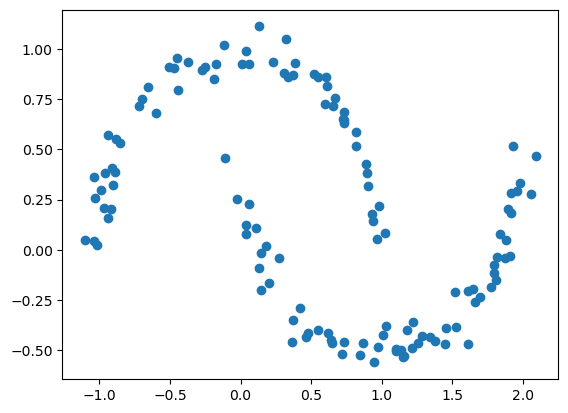

In [25]:
scatter(samples[-1,:,0], samples[-1,:,1])

### Testing variable splitting approach